# Transformers from Scratch
### An Introductory Lecture with PyTorch Implementations

This notebook has two parts:
- **📘 General Intro (Parts 0–5):** Build a full Transformer sentiment classifier from scratch. Requires familiarity with neural networks (CNNs / RNNs) but not with attention.
- **🔬 Deeper Dive (Part 6):** Mathematical deep dives — scaling, normalization order, positional encoding variants, attention efficiency, and training tricks.

**Dependencies:** `torch`, `numpy`, `matplotlib`.

## Useful Materials
- https://jalammar.github.io/illustrated-transformer/
- RNNS: https://arxiv.org/pdf/1412.3555
- Transformer Paper: https://arxiv.org/pdf/1706.03762

---
## Part 0 — Motivation: Why Transformers?

### The problem with RNNs

Recurrent networks (RNNs, LSTMs, GRUs) process sequences token-by-token:

```
Input:    x1 -> x2 -> x3 -> x4
            |    |    |    |
Hidden:   h1 -> h2 -> h3 -> h4  ->  output
```

| Problem | Description |
|---|---|
| **Sequential compute** | h4 depends on h3 -> h2 -> h1: no parallelism over time |
| **Vanishing gradients** | Gradients shrink over long sequences — hard to learn long-range dependencies |
| **Fixed-size bottleneck** | Seq2seq must compress an entire input into one vector h_T |

**Transformers** replace recurrence with **self-attention**: every token attends to every other token simultaneously.

```
Input:    x1   x2   x3   x4
           |    |    |    |    <- all pairs in parallel
Output:   y1   y2   y3   y4
```

In [26]:
import subprocess, sys
try:
    import torch
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "torch"])
    import torch

import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# ---- Device selection: CUDA > MPS > CPU ----
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print(f"PyTorch {torch.__version__}")
print(f"Device  : {DEVICE}")

# ---- Reproducibility ----
SEED = 42

def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if DEVICE.type == "cuda":
        torch.cuda.manual_seed_all(seed)
    elif DEVICE.type == "mps":
        torch.mps.manual_seed(seed)

set_seed()

PyTorch 2.9.1
Device  : mps


### "Attention Is All You Need" — Vaswani et al., 2017

The paper introduced an architecture built entirely from attention — no recurrence, no convolutions. Key insight: **attention can capture any dependency between positions regardless of distance**, while being fully parallelisable.

```
                   +----------------------------+
                   |         DECODER            |
 Target tokens ->  |  [Embed + PE]              |
                   |  [Masked Self-Attn]        |
                   |  [Cross-Attn <- Encoder]   |  -> Output logits
                   |  [Feed-Forward]            |
                   |  x N blocks                |
                   +----------------------------+
                            ^ encoder memory
                   +----------------------------+
                   |         ENCODER            |
 Source tokens ->  |  [Embed + PE]              |
                   |  [Self-Attention]          |
                   |  [Feed-Forward]            |
                   |  x N blocks                |
                   +----------------------------+
```

In this lecture we build the **encoder stack** and apply it to sentiment classification.

---
## Part 1 — Scaled Dot-Product Attention

### Query, Key, Value — the database analogy

Think of attention as a **soft database lookup**:
- **Query (Q):** what you're searching for
- **Key (K):** the index of each entry
- **Value (V):** the content stored at each entry

For each query we measure compatibility with every key (dot product), normalise (softmax), and take the weighted sum of values:

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right) V$$

- $Q \in \mathbb{R}^{n \times d_k}$, $K \in \mathbb{R}^{m \times d_k}$, $V \in \mathbb{R}^{m \times d_v}$
- $\sqrt{d_k}$ prevents dot products from growing too large (see Part 6.1 for the derivation)
- Output shape: $(n \times d_v)$ — each of the $n$ queries gets a weighted mixture of the $m$ values

In [27]:
def scaled_dot_product_attention(Q, K, V, mask=None, dropout=None):
    """
    Q: (batch, heads, seq_q, d_k)
    K: (batch, heads, seq_k, d_k)
    V: (batch, heads, seq_k, d_v)
    mask: (batch, 1, 1, seq_k) bool -- True means blocked (broadcasts over heads and queries)
    Returns: output (batch, heads, seq_q, d_v), weights (batch, heads, seq_q, seq_k)
    """
    d_k = Q.size(-1)
    scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)
    if mask is not None:
        scores = scores.masked_fill(mask, float('-inf'))
    weights = F.softmax(scores, dim=-1)
    if dropout is not None:
        weights = dropout(weights)
    return torch.matmul(weights, V), weights

In [28]:
# Toy demo: 4 tokens, d_k = d_v = 8
torch.manual_seed(0)
batch, seq, d_k = 1, 4, 8
Q = torch.randn(batch, 1, seq, d_k)
K = torch.randn(batch, 1, seq, d_k)
V = torch.randn(batch, 1, seq, d_k)

out, weights = scaled_dot_product_attention(Q, K, V)
print(f"Output shape : {out.shape}")       # (1, 1, 4, 8)
print(f"Weights shape: {weights.shape}")   # (1, 1, 4, 4)
print(f"\nAttention weight matrix (4x4):")
print(weights[0, 0].detach().numpy().round(3))

Output shape : torch.Size([1, 1, 4, 8])
Weights shape: torch.Size([1, 1, 4, 4])

Attention weight matrix (4x4):
[[0.121 0.741 0.106 0.032]
 [0.258 0.265 0.171 0.307]
 [0.336 0.017 0.187 0.46 ]
 [0.203 0.623 0.102 0.071]]


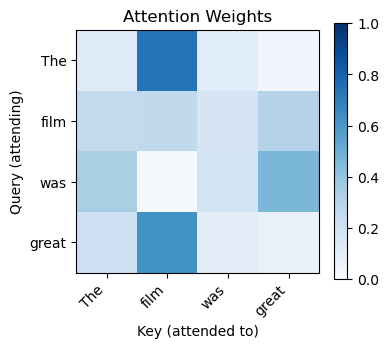

In [29]:
tokens = ["The", "film", "was", "great"]
fig, ax = plt.subplots(figsize=(4, 3.5))
im = ax.imshow(weights[0, 0].detach().numpy(), cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(tokens))); ax.set_yticks(range(len(tokens)))
ax.set_xticklabels(tokens, rotation=45, ha="right")
ax.set_yticklabels(tokens)
ax.set_xlabel("Key (attended to)"); ax.set_ylabel("Query (attending)")
ax.set_title("Attention Weights")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

---
## Part 2 — Multi-Head Attention

Running attention once restricts the model to one type of relationship per layer. Multi-head attention runs $h$ attention functions in parallel on different learned projections, then concatenates and projects:

$$\text{MultiHead}(Q,K,V) = \text{Concat}(\text{head}_1, \ldots, \text{head}_h)\, W^O$$
$$\text{head}_i = \text{Attention}(QW^Q_i,\; KW^K_i,\; VW^V_i)$$

- Each head operates in $d_k = d_{\text{model}} / h$
- Different heads can specialise: syntax, coreference, proximity, etc.
- Total parameter count stays the same as single-head with $d_{\text{model}}$

In [30]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout=0.1):
        super().__init__()
        assert d_model % num_heads == 0
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        self.W_o = nn.Linear(d_model, d_model, bias=False)
        self.dropout = nn.Dropout(dropout)

    def _split_heads(self, x):
        B, S, _ = x.size()
        return x.view(B, S, self.num_heads, self.d_k).transpose(1, 2)

    def forward(self, query, key, value, mask=None):
        Q = self._split_heads(self.W_q(query))  # (B, heads, S, d_k)
        K = self._split_heads(self.W_k(key))
        V = self._split_heads(self.W_v(value))

        attn_out, self.attn_weights = scaled_dot_product_attention(Q, K, V, mask, self.dropout)

        B, _, S, _ = attn_out.size()
        merged = attn_out.transpose(1, 2).contiguous().view(B, S, self.d_model)
        return self.W_o(merged)

In [31]:
mha = MultiHeadAttention(d_model=64, num_heads=4)
x = torch.randn(2, 8, 64)   # batch=2, seq=8, d_model=64
out = mha(x, x, x)
assert out.shape == (2, 8, 64)
print(f"MHA output shape : {out.shape}  OK")
print(f"Per-head dim d_k : {mha.d_k}")

MHA output shape : torch.Size([2, 8, 64])  OK
Per-head dim d_k : 16


---
## Part 3 — Positional Encoding

Self-attention is **permutation-invariant** — it produces identical output regardless of token order. We add a fixed positional signal to the embeddings before the first encoder block.

The original paper uses **sinusoidal encoding**:

$$PE_{(pos,\, 2i)} = \sin\!\left(\frac{pos}{10000^{2i/d_{\text{model}}}}\right), \qquad
PE_{(pos,\, 2i+1)} = \cos\!\left(\frac{pos}{10000^{2i/d_{\text{model}}}}\right)$$

Properties:
- Each position gets a unique fixed vector
- Relative positions are representable as linear transformations
- Can generalise to unseen lengths at inference

In [32]:
class SinusoidalPositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))  # (1, max_len, d_model)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)

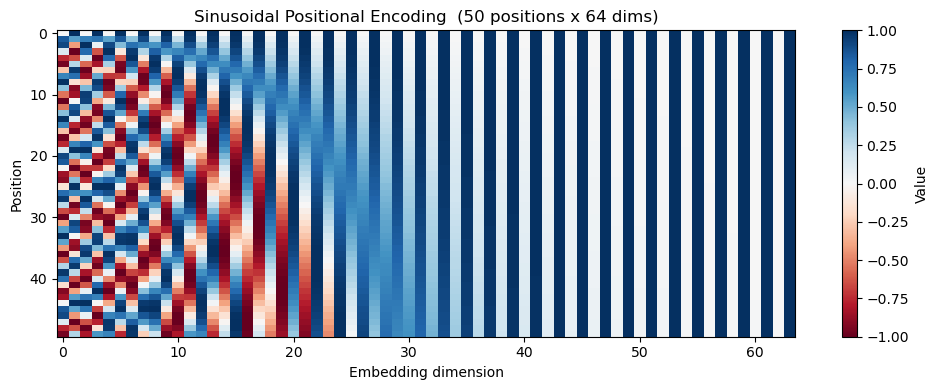

In [33]:
pe_module = SinusoidalPositionalEncoding(d_model=64, max_len=50, dropout=0.0)
pe_matrix = pe_module.pe[0].numpy()   # (50, 64)

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(pe_matrix, aspect='auto', cmap='RdBu', vmin=-1, vmax=1)
ax.set_xlabel("Embedding dimension")
ax.set_ylabel("Position")
ax.set_title("Sinusoidal Positional Encoding  (50 positions x 64 dims)")
plt.colorbar(im, ax=ax, label="Value")
plt.tight_layout()
plt.show()

---
## Part 4 — Transformer Encoder Block

Each encoder block applies two sublayers, each wrapped in a **residual connection** and **Layer Normalization**:

```
x -> [Multi-Head Self-Attention] -> +x -> LayerNorm -> [Feed-Forward] -> +x -> LayerNorm
```

The **Feed-Forward** sublayer is a 2-layer MLP applied independently at each position:

$$\text{FFN}(x) = \text{ReLU}(xW_1 + b_1)W_2 + b_2$$

with inner dimension typically $4 \times d_{\text{model}}$. Residual connections enable gradient flow; LayerNorm stabilises activations (per-token, not per-batch).

In [34]:
class FeedForward(nn.Module):
    def __init__(self, d_model, ff_dim, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, ff_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim, d_model),
        )

    def forward(self, x):
        return self.net(x)


class TransformerEncoderBlock(nn.Module):
    def __init__(self, d_model, num_heads, ff_dim, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.ff        = FeedForward(d_model, ff_dim, dropout)
        self.norm1     = nn.LayerNorm(d_model)
        self.norm2     = nn.LayerNorm(d_model)
        self.drop1     = nn.Dropout(dropout)
        self.drop2     = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        # Sublayer 1: self-attention + residual + post-norm
        x = self.norm1(x + self.drop1(self.self_attn(x, x, x, mask)))
        # Sublayer 2: feed-forward + residual + post-norm
        x = self.norm2(x + self.drop2(self.ff(x)))
        return x


class TransformerEncoder(nn.Module):
    def __init__(self, d_model, num_heads, ff_dim, num_layers, dropout=0.1):
        super().__init__()
        self.layers = nn.ModuleList([
            TransformerEncoderBlock(d_model, num_heads, ff_dim, dropout)
            for _ in range(num_layers)
        ])

    def forward(self, x, mask=None):
        for layer in self.layers:
            x = layer(x, mask)
        return x


# Test
encoder = TransformerEncoder(d_model=64, num_heads=4, ff_dim=128, num_layers=2)
x_test = torch.randn(2, 8, 64)
out_test = encoder(x_test)
assert out_test.shape == x_test.shape
print(f"Encoder output shape: {out_test.shape}  OK")

Encoder output shape: torch.Size([2, 8, 64])  OK


---
## Part 5 — End-to-End: Sentiment Classifier

We assemble the full pipeline:

```
Token IDs -> Embedding -> Positional Encoding -> [Encoder Block] x N -> Mean Pool -> Linear -> Logits
```

**Mean pooling** averages over all token positions to get a fixed-size sentence representation. The toy dataset is 60 hand-crafted sentences (30 positive, 30 negative) — no external downloads required.

In [35]:
POSITIVE = [
    "this movie was absolutely fantastic and I loved every moment",
    "the acting was brilliant and the story was deeply moving",
    "a wonderful film that left me feeling inspired",
    "the best movie I have seen in years",
    "outstanding performance by the entire cast",
    "incredibly well crafted with beautiful cinematography",
    "a masterpiece that deserves all the awards",
    "I was captivated from start to finish",
    "the story was heartwarming and the characters were charming",
    "superb direction and an unforgettable ending",
    "a delightful and uplifting experience",
    "the film exceeded all my expectations",
    "a truly remarkable piece of cinema",
    "the plot was engaging and the pacing was perfect",
    "one of the most touching stories I have ever seen",
    "loved the creativity and originality of this film",
    "a joyful and entertaining ride throughout",
    "the humor was spot on and the cast was excellent",
    "absolutely loved this film from beginning to end",
    "an emotionally powerful and well acted film",
    "this was a refreshing and genuinely enjoyable watch",
    "the script was sharp and the performances were stellar",
    "a beautiful story told with great care and skill",
    "the film was a complete delight and very well made",
    "exceptional storytelling and stunning visuals",
    "I thoroughly enjoyed every aspect of this production",
    "the chemistry between the leads was electric and believable",
    "a thoughtful and inspiring film well worth watching",
    "compelling narrative with memorable and likable characters",
    "a feel good film that really delivers on every level",
]

NEGATIVE = [
    "this film was a complete waste of time and money",
    "the acting was terrible and the plot made no sense",
    "I was bored from the very first scene to the last",
    "an absolute disaster of a movie with no redeeming qualities",
    "the writing was lazy and the characters were annoying",
    "poorly directed and painfully slow throughout",
    "one of the worst films I have ever had to sit through",
    "the story was incoherent and the ending was a letdown",
    "dreadful performances all around and a forgettable script",
    "a deeply disappointing and frustrating experience",
    "the film had no heart and felt completely hollow",
    "a boring and predictable mess with terrible dialogue",
    "I hated almost everything about this movie",
    "overlong and tedious with nothing interesting to say",
    "the plot holes were enormous and the pacing was awful",
    "a cliched and uninspired film that felt like a chore to watch",
    "the characters were flat and I did not care about any of them",
    "a total failure in every department of filmmaking",
    "the cinematography was ugly and the music was grating",
    "this movie was offensive mediocre and thoroughly unenjoyable",
    "I fell asleep halfway through it was so dull",
    "the worst screenplay I have encountered in recent memory",
    "an embarrassing effort that nobody should have to endure",
    "devoid of any originality or genuine emotion",
    "the film dragged on with nothing of substance to offer",
    "a humorless and joyless slog that wastes talented actors",
    "every scene felt forced and the dialogue was cringe worthy",
    "a soulless production that exists purely for a cash grab",
    "the whole thing felt lazy and poorly thought out",
    "a spectacular failure that leaves the viewer cold and annoyed",
]

sentences = POSITIVE + NEGATIVE
labels    = [1] * len(POSITIVE) + [0] * len(NEGATIVE)

def tokenize(text):
    return text.lower().split()

word_counts = Counter(w for s in sentences for w in tokenize(s))
# <PAD> (index 0): filler token appended to short sequences so all inputs in a batch share the same length.
#   The model masks these positions out during attention and mean pooling so they don't affect the output.
# <UNK> (index 1): substituted for any word at inference time that wasn't seen during training.
vocab = {"<PAD>": 0, "<UNK>": 1}
for word in word_counts:
    vocab[word] = len(vocab)

MAX_LEN = 20

def encode(sentence, max_len=MAX_LEN):
    tokens = tokenize(sentence)[:max_len]
    ids    = [vocab.get(t, vocab["<UNK>"]) for t in tokens]  # out-of-vocab words fall back to <UNK>
    ids   += [vocab["<PAD>"]] * (max_len - len(ids))          # right-pad to MAX_LEN
    return ids

X = torch.tensor([encode(s) for s in sentences], dtype=torch.long)
Y = torch.tensor(labels, dtype=torch.long)

print(f"Vocabulary size : {len(vocab)}")
print(f"X shape         : {X.shape}")
print(f"Y distribution  : {Y.sum().item()} positive, {(Y==0).sum().item()} negative")

torch.manual_seed(42)
idx   = torch.randperm(len(X))
split = int(0.8 * len(X))
X_train, Y_train = X[idx[:split]], Y[idx[:split]]
X_val,   Y_val   = X[idx[split:]], Y[idx[split:]]

Vocabulary size : 255
X shape         : torch.Size([60, 20])
Y distribution  : 30 positive, 30 negative


In [36]:
class SentimentTransformer(nn.Module):
    def __init__(self, vocab_size, d_model=64, num_heads=4, ff_dim=128,
                 num_layers=2, num_classes=2, max_len=MAX_LEN, dropout=0.1):
        super().__init__()
        self.embedding  = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.pos_enc    = SinusoidalPositionalEncoding(d_model, max_len, dropout)
        self.encoder    = TransformerEncoder(d_model, num_heads, ff_dim, num_layers, dropout)
        self.classifier = nn.Linear(d_model, num_classes)

    def forward(self, x):
        ids = x
        pad_mask = (x == 0).unsqueeze(1).unsqueeze(2)   # (B, 1, 1, seq)
        x = self.embedding(x)                            # (B, seq, d_model)
        x = self.pos_enc(x)
        x = self.encoder(x, mask=pad_mask)
        pad = (ids == 0).unsqueeze(-1)                  # (B, seq, 1)
        x = x.masked_fill(pad, 0.0).sum(1) / (~pad).sum(1).clamp(min=1)  # masked mean
        return self.classifier(x)


set_seed()
model = SentimentTransformer(vocab_size=len(vocab)).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {n_params:,}")
print(f"Model device    : {DEVICE}")

dummy = torch.randint(0, len(vocab), (4, MAX_LEN), device=DEVICE)
assert model(dummy).shape == (4, 2)
print(f"Output logit shape: {model(dummy).shape}  OK")

Model parameters: 82,882
Model device    : mps
Output logit shape: torch.Size([4, 2])  OK


Epoch  10 | train_loss=0.3650 | val_loss=0.7828 | val_acc=50.00%
Epoch  20 | train_loss=0.0148 | val_loss=1.4970 | val_acc=58.33%
Epoch  30 | train_loss=0.0021 | val_loss=2.3693 | val_acc=58.33%
Epoch  40 | train_loss=0.0006 | val_loss=2.7919 | val_acc=58.33%


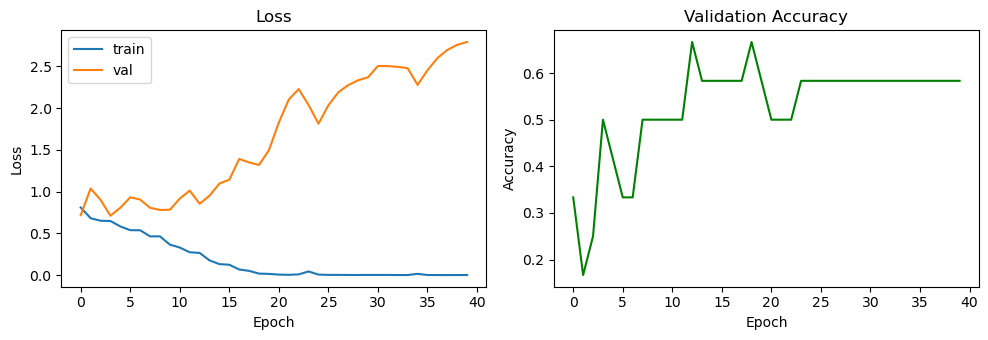

In [37]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()
EPOCHS, BATCH = 40, 16

# Move full dataset to device once (dataset is tiny)
X_train_d, Y_train_d = X_train.to(DEVICE), Y_train.to(DEVICE)
X_val_d,   Y_val_d   = X_val.to(DEVICE),   Y_val.to(DEVICE)

train_losses, val_losses, val_accs = [], [], []

for epoch in range(1, EPOCHS + 1):
    model.train()
    perm       = torch.randperm(len(X_train_d), device=DEVICE)
    epoch_loss = 0.0
    for i in range(0, len(X_train_d), BATCH):
        idx = perm[i:i+BATCH]
        xb, yb = X_train_d[idx], Y_train_d[idx]
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        epoch_loss += loss.item() * len(xb)
    epoch_loss /= len(X_train_d)

    model.eval()
    with torch.no_grad():
        val_logits = model(X_val_d)
        vl = criterion(val_logits, Y_val_d).item()
        va = (val_logits.argmax(1) == Y_val_d).float().mean().item()

    train_losses.append(epoch_loss)
    val_losses.append(vl)
    val_accs.append(va)

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | train_loss={epoch_loss:.4f} | val_loss={vl:.4f} | val_acc={va:.2%}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5))
ax1.plot(train_losses, label="train"); ax1.plot(val_losses, label="val")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss"); ax1.legend(); ax1.set_title("Loss")
ax2.plot(val_accs, color="green")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy"); ax2.set_title("Validation Accuracy")
plt.tight_layout(); plt.show()

In [38]:
def predict(sentence):
    model.eval()
    ids = torch.tensor([encode(sentence)], device=DEVICE)
    with torch.no_grad():
        probs = F.softmax(model(ids), dim=-1)[0]
    label = "Positive" if probs[1] > probs[0] else "Negative"
    return label, max(probs).item()

test_sentences = [
    "a stunning and deeply moving cinematic experience",
    "poorly written with a predictable and boring plot",
    "the performances were mediocre and uninspiring",
    "an absolute joy to watch with a wonderful cast",
    "I regret watching this film it was so bad",
]

print(f"{'Sentence':<55} {'Prediction':<12} {'Confidence':>10}")
print("-" * 80)
for s in test_sentences:
    label, conf = predict(s)
    print(f"{s:<55} {label:<12} {conf:>10.2%}")

# Note: some predictions are confidently wrong (e.g. "an absolute joy" -> Negative).
# "absolute" appears only in "an absolute disaster" in training, so the model over-indexes on it.
# This is expected on a 60-sentence toy dataset — use a real corpus for reliable results.

Sentence                                                Prediction   Confidence
--------------------------------------------------------------------------------
a stunning and deeply moving cinematic experience       Positive         88.45%
poorly written with a predictable and boring plot       Negative         99.96%
the performances were mediocre and uninspiring          Negative         99.93%
an absolute joy to watch with a wonderful cast          Negative         99.98%
I regret watching this film it was so bad               Positive         85.84%


### Where to go next

| Extension | How |
|---|---|
| **Real datasets** | `pip install datasets` then `load_dataset("sst2")` or `"imdb"` |
| **Larger model** | Increase `d_model`, `num_layers`, `ff_dim` and train on GPU |
| **Pre-trained weights** | Swap encoder for `transformers.BertModel` (HuggingFace) |
| **PyTorch built-ins** | Replace with `nn.TransformerEncoder` + `nn.TransformerEncoderLayer` |
| **Causal LM** | Add a causal mask to get a mini-GPT (see Part 6.5) |

The conceptual building blocks implemented here — scaled dot-product attention, multi-head attention, positional encoding, residual connections, and normalization — are the foundation of modern Transformers. Production models differ in specifics: BERT uses learned positional embeddings and GELU; GPT-2/3/4 use learned PE and Pre-Norm; LLaMA uses RoPE, Pre-Norm, SwiGLU, and RMSNorm. The core ideas are the same.

---
---
# Deeper Dive — Advanced Deep Dives

The following sections contain mathematical deep dives into design decisions that practitioners often take for granted. Each section is self-contained.

## 6.1 — Why divide by sqrt(d_k)?

### The variance argument

Assume $q_i, k_j \sim \mathcal{N}(0, 1)$ i.i.d. (roughly true post-LayerNorm). The dot product $q \cdot k = \sum_{i=1}^{d_k} q_i k_i$ has:
- $\mathbb{E}[q_i k_i] = 0$
- $\text{Var}[q_i k_i] = \mathbb{E}[q_i^2]\mathbb{E}[k_i^2] = 1$  (by independence)
- $\text{Var}[q \cdot k] = d_k$, so $\text{Std}[q \cdot k] = \sqrt{d_k}$

Therefore $q \cdot k / \sqrt{d_k}$ has **unit variance regardless of $d_k$**.

**Why does large variance harm training?**  
If pre-softmax logits have large magnitude, softmax saturates — one position gets probability ~1, the rest ~0. The gradient of a saturated softmax is ~0 everywhere: vanishing gradients, the model can no longer update its attention distribution.

The plot below shows softmax **entropy** (higher = more diffuse = healthier) vs $d_k$.

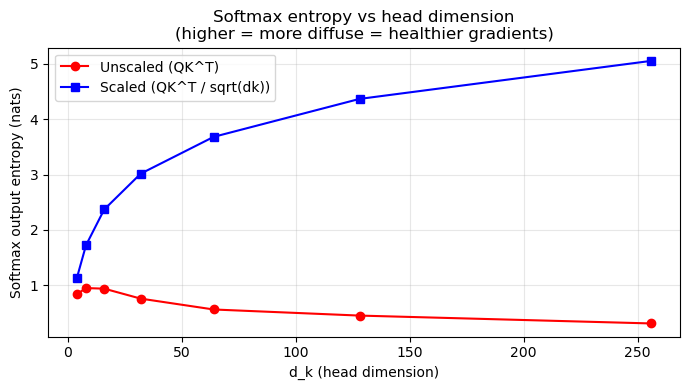

Without scaling, entropy collapses as d_k grows -> attention becomes a hard argmax -> vanishing gradients


In [39]:
def softmax_entropy(logits):
    p = F.softmax(logits, dim=-1)
    return -(p * (p + 1e-9).log()).sum(-1).mean().item()

torch.manual_seed(0)
d_ks = [4, 8, 16, 32, 64, 128, 256]
ent_raw, ent_scaled = [], []

for d_k in d_ks:
    Q_b = torch.randn(500, 1, d_k)
    K_b = torch.randn(500, d_k, d_k)
    scores = torch.bmm(Q_b, K_b.transpose(1, 2)).squeeze(1)   # (500, d_k)
    ent_raw.append(softmax_entropy(scores))
    ent_scaled.append(softmax_entropy(scores / math.sqrt(d_k)))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(d_ks, ent_raw,    'o-r', label='Unscaled (QK^T)')
ax.plot(d_ks, ent_scaled, 's-b', label='Scaled (QK^T / sqrt(dk))')
ax.set_xlabel('d_k (head dimension)')
ax.set_ylabel('Softmax output entropy (nats)')
ax.set_title('Softmax entropy vs head dimension\n(higher = more diffuse = healthier gradients)')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
print("Without scaling, entropy collapses as d_k grows -> attention becomes a hard argmax -> vanishing gradients")

## 6.2 — Pre-Norm vs Post-Norm

The original paper uses **Post-Norm** (add residual, then normalise):
```
Post-Norm:  x = LayerNorm(x + Sublayer(x))
```

Modern large models (GPT-2, PaLM, LLaMA) use **Pre-Norm** (normalise inputs first):
```
Pre-Norm:   x = x + Sublayer(LayerNorm(x))
```

**Why Pre-Norm dominates today:**
- Post-Norm gradients are large in early layers during initial training, requiring careful warmup
- Pre-Norm keeps gradient magnitudes more uniform across depth — supports larger LR, more stable
- Trade-off: pre-norm sometimes converges to slightly worse final loss

The implementation difference is **one line**.

Training Post-Norm...
Training Pre-Norm...


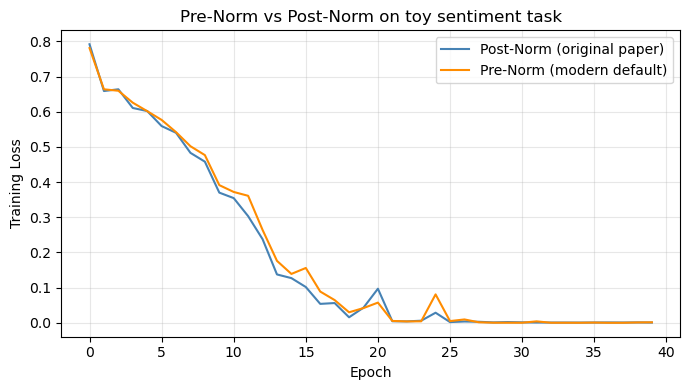

In [40]:
class PreNormTransformerBlock(nn.Module):
    def __init__(self, d_model, num_heads, ff_dim, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.ff    = FeedForward(d_model, ff_dim, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.drop1 = nn.Dropout(dropout)
        self.drop2 = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        xn = self.norm1(x)
        x  = x + self.drop1(self.self_attn(xn, xn, xn, mask))   # pre-norm
        x  = x + self.drop2(self.ff(self.norm2(x)))
        return x


def train_variant(block_cls, seed=42, epochs=40):
    set_seed(seed)

    class _Model(nn.Module):
        def __init__(self):
            super().__init__()
            self.emb  = nn.Embedding(len(vocab), 64, padding_idx=0)
            self.pe   = SinusoidalPositionalEncoding(64, MAX_LEN, 0.1)
            self.blks = nn.ModuleList([block_cls(64, 4, 128, 0.1) for _ in range(2)])
            self.clf  = nn.Linear(64, 2)

        def forward(self, x):
            mask = (x == 0).unsqueeze(1).unsqueeze(2)
            x = self.pe(self.emb(x))
            for blk in self.blks: x = blk(x, mask)
            return self.clf(x.mean(1))

    m   = _Model().to(DEVICE)
    opt = torch.optim.Adam(m.parameters(), lr=1e-3)
    Xtr = X_train.to(DEVICE)
    Ytr = Y_train.to(DEVICE)
    losses = []
    for _ in range(epochs):
        m.train()
        perm = torch.randperm(len(Xtr), device=DEVICE)
        ep   = 0.0
        for i in range(0, len(Xtr), 16):
            xb, yb = Xtr[perm[i:i+16]], Ytr[perm[i:i+16]]
            opt.zero_grad()
            loss = criterion(m(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(m.parameters(), 1.0)
            opt.step()
            ep += loss.item() * len(xb)
        losses.append(ep / len(Xtr))
    return losses

print("Training Post-Norm...")
post_losses = train_variant(TransformerEncoderBlock)
print("Training Pre-Norm...")
pre_losses  = train_variant(PreNormTransformerBlock)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(post_losses, label='Post-Norm (original paper)', color='steelblue')
ax.plot(pre_losses,  label='Pre-Norm (modern default)',  color='darkorange')
ax.set_xlabel('Epoch'); ax.set_ylabel('Training Loss')
ax.set_title('Pre-Norm vs Post-Norm on toy sentiment task')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 6.3 — Attention Complexity and the Path to FlashAttention

Standard self-attention computes an $n \times n$ score matrix: **$O(n^2 d)$ FLOPs, $O(n^2)$ memory** — the fundamental barrier to long-context models.

**FlashAttention (Dao et al., 2022)** avoids materialising the full $n \times n$ matrix by computing in **tiles** that fit in GPU SRAM:
1. Divide Q, K, V into blocks that fit in fast on-chip memory
2. Compute softmax incrementally via the online log-sum-exp trick
3. Accumulate output without ever writing the full attention matrix to slow HBM

**Result:** same numerical output, $O(n)$ memory, 2–4x faster wall-clock on long sequences.

PyTorch >= 2.0 exposes this via `F.scaled_dot_product_attention`, which dispatches to FlashAttention when available.

seq_len=  64 | manual=0.108ms | F.sdpa=0.053ms
seq_len= 128 | manual=0.188ms | F.sdpa=0.075ms
seq_len= 256 | manual=0.460ms | F.sdpa=0.243ms
seq_len= 512 | manual=1.857ms | F.sdpa=0.595ms


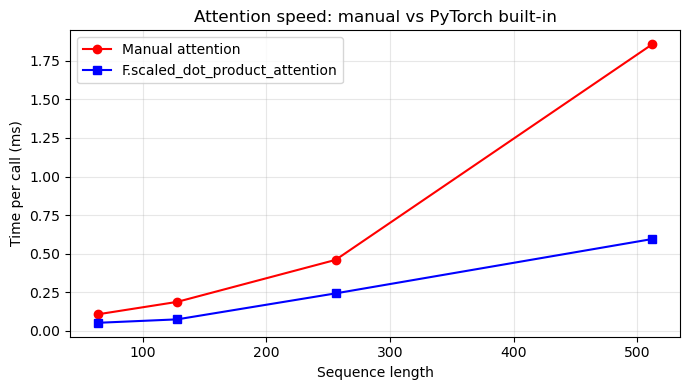

In [41]:
import time

seq_lens = [64, 128, 256, 512]
H, DK    = 4, 16   # heads, head-dim
results  = []

for seq_len in seq_lens:
    Q_ = torch.randn(1, H, seq_len, DK)
    K_ = torch.randn(1, H, seq_len, DK)
    V_ = torch.randn(1, H, seq_len, DK)

    t0 = time.perf_counter()
    for _ in range(100):
        scaled_dot_product_attention(Q_, K_, V_)
    t_manual = (time.perf_counter() - t0) / 100 * 1000

    t0 = time.perf_counter()
    for _ in range(100):
        F.scaled_dot_product_attention(Q_, K_, V_)
    t_builtin = (time.perf_counter() - t0) / 100 * 1000

    results.append((seq_len, t_manual, t_builtin))
    print(f"seq_len={seq_len:4d} | manual={t_manual:.3f}ms | F.sdpa={t_builtin:.3f}ms")

fig, ax = plt.subplots(figsize=(7, 4))
seqs = [r[0] for r in results]
ax.plot(seqs, [r[1] for r in results], 'o-r', label='Manual attention')
ax.plot(seqs, [r[2] for r in results], 's-b', label='F.scaled_dot_product_attention')
ax.set_xlabel('Sequence length'); ax.set_ylabel('Time per call (ms)')
ax.set_title('Attention speed: manual vs PyTorch built-in')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 6.4 — Rotary Positional Encoding (RoPE)

**Problem with absolute PE:** sinusoidal encodings are added to embeddings, so the model must implicitly learn how position shifts interact with attention — indirect and brittle for long contexts.

**RoPE (Su et al., 2021)** encodes positions by **rotating** Q and K vectors before computing attention. For a 2D slice $(x_{2i}, x_{2i+1})$ at position $m$:

$$\begin{pmatrix} x'_{2i} \\ x'_{2i+1} \end{pmatrix} = \begin{pmatrix} \cos m\theta_i & -\sin m\theta_i \\ \sin m\theta_i & \cos m\theta_i \end{pmatrix} \begin{pmatrix} x_{2i} \\ x_{2i+1} \end{pmatrix}, \quad \theta_i = 10000^{-2i/d}$$

**Key property:** $q'_m \cdot k'_n$ depends **only on the relative position** $(m - n)$, not on absolute $m$ or $n$ separately. We verify this empirically below.

RoPE is used in LLaMA, Mistral, Gemma, and most current production LLMs.

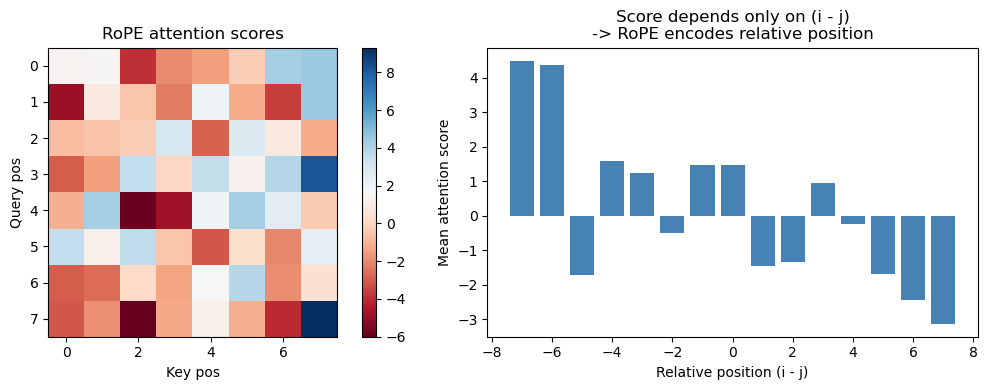

In [42]:
def build_rope_cache(seq_len, d_head, base=10000):
    theta = 1.0 / (base ** (torch.arange(0, d_head, 2).float() / d_head))
    t     = torch.arange(seq_len).float()
    freqs = torch.outer(t, theta)                  # (seq_len, d_head/2)
    cos   = freqs.cos().unsqueeze(0).unsqueeze(0)  # (1, 1, seq_len, d_head/2)
    sin   = freqs.sin().unsqueeze(0).unsqueeze(0)
    return cos, sin

def rotate_half(x):
    x1, x2 = x[..., ::2], x[..., 1::2]
    return torch.stack([-x2, x1], dim=-1).flatten(-2)

def apply_rope(x, cos, sin):
    cos_full = cos.repeat_interleave(2, dim=-1)
    sin_full = sin.repeat_interleave(2, dim=-1)
    return x * cos_full + rotate_half(x) * sin_full


torch.manual_seed(0)
seq_len, d_head = 8, 16
cos, sin = build_rope_cache(seq_len, d_head)
q_r = torch.randn(1, 1, seq_len, d_head)
k_r = torch.randn(1, 1, seq_len, d_head)
q_rope = apply_rope(q_r, cos, sin)
k_rope = apply_rope(k_r, cos, sin)

scores = torch.einsum('bhid,bhjd->bhij', q_rope, k_rope)[0, 0].detach()

# Group scores by relative position (i - j)
rel_pos = {}
for i in range(seq_len):
    for j in range(seq_len):
        rel_pos.setdefault(i - j, []).append(scores[i, j].item())

rel_keys = sorted(rel_pos.keys())
rel_vals = [np.mean(rel_pos[k]) for k in rel_keys]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
im = axes[0].imshow(scores.numpy(), cmap='RdBu')
axes[0].set_title('RoPE attention scores')
axes[0].set_xlabel('Key pos'); axes[0].set_ylabel('Query pos')
plt.colorbar(im, ax=axes[0])

axes[1].bar(rel_keys, rel_vals, color='steelblue')
axes[1].set_xlabel('Relative position (i - j)')
axes[1].set_ylabel('Mean attention score')
axes[1].set_title('Score depends only on (i - j)\n-> RoPE encodes relative position')
plt.tight_layout(); plt.show()

## 6.5 — Architectural Variants

| Model type | Masking | Pre-training objective | Examples |
|---|---|---|---|
| **Encoder-only** | Bidirectional | Masked Language Modelling | BERT, RoBERTa, DeBERTa |
| **Decoder-only** | Causal (left-to-right) | Causal Language Modelling | GPT-2/3/4, LLaMA, Mistral |
| **Encoder-Decoder** | Enc: bi, Dec: causal | Span denoising / seq2seq | T5, BART, mT5 |

**When to use which:**
- **Encoder-only:** Classification, NER, retrieval — tasks needing rich bidirectional representations
- **Decoder-only:** Generation — "predict next token given context" is the natural framing
- **Encoder-Decoder:** Conditional generation where input and output live in different domains

The single change that converts our encoder to a causal decoder is a **causal mask** — upper-triangular, blocking each position from attending to future ones.

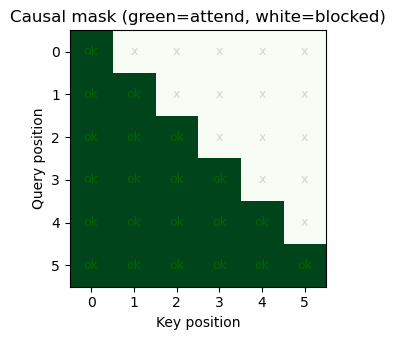

Causal decoder output shape: torch.Size([1, 6, 64])  OK
Each position can only attend to itself and earlier positions.


In [43]:
def causal_mask(seq_len):
    """True = blocked (upper triangle, excluding diagonal)"""
    return torch.triu(torch.ones(seq_len, seq_len, dtype=torch.bool), diagonal=1)

seq_len_c = 6
mask_cm = causal_mask(seq_len_c)

fig, ax = plt.subplots(figsize=(4.5, 3.5))
ax.imshow(~mask_cm, cmap='Greens', vmin=0, vmax=1)
ax.set_title("Causal mask (green=attend, white=blocked)")
ax.set_xlabel("Key position"); ax.set_ylabel("Query position")
for i in range(seq_len_c):
    for j in range(seq_len_c):
        ax.text(j, i, "ok" if not mask_cm[i, j] else "x",
                ha='center', va='center', fontsize=9,
                color='darkgreen' if not mask_cm[i, j] else 'lightgray')
plt.tight_layout(); plt.show()

# Plug causal mask into existing encoder block -> it becomes a causal decoder
causal_4d = mask_cm.unsqueeze(0).unsqueeze(0)   # (1, 1, seq, seq)
block_dec = TransformerEncoderBlock(64, 4, 128)
x_dec = torch.randn(1, seq_len_c, 64)
out_dec = block_dec(x_dec, mask=causal_4d)
print(f"Causal decoder output shape: {out_dec.shape}  OK")
print("Each position can only attend to itself and earlier positions.")

## 6.6 — Training Tricks

### Noam Learning Rate Schedule

The original paper uses a custom schedule: linear warmup then inverse-sqrt decay:

$$lr = d_{\text{model}}^{-0.5} \cdot \min\!\left(\text{step}^{-0.5},\; \text{step} \cdot \text{warmup}^{-1.5}\right)$$

- **Warmup phase:** LR grows linearly — avoids instability with random init
- **Decay phase:** proportional to $1/\sqrt{\text{step}}$ — fine-grained refinement as training converges

### Gradient clipping
```python
nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
```
Prevents gradient explosion — especially important early in training when attention scores can spike.

### Label smoothing
Replace hard targets $[0, 1]$ with soft targets $[\varepsilon/K,\; 1 - \varepsilon + \varepsilon/K]$. Prevents overconfidence; acts as a regulariser. In PyTorch: `nn.CrossEntropyLoss(label_smoothing=0.1)`.

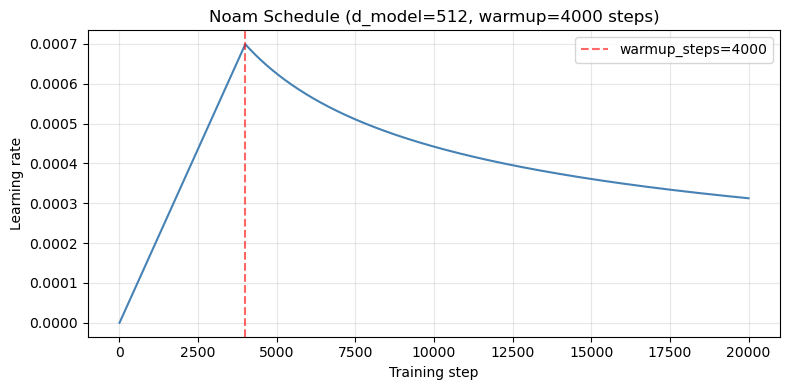

Peak LR: 0.000699  at step 4001


In [44]:
def get_noam_schedule(optimizer, d_model, warmup_steps=4000):
    def lr_lambda(step):
        step = max(1, step)
        return (d_model ** -0.5) * min(step ** -0.5, step * warmup_steps ** -1.5)
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


dummy_model = nn.Linear(1, 1)
dummy_opt   = torch.optim.Adam(dummy_model.parameters(), lr=1.0)
scheduler   = get_noam_schedule(dummy_opt, d_model=512, warmup_steps=4000)

lrs = []
for _ in range(20000):
    dummy_opt.step()
    lrs.append(dummy_opt.param_groups[0]['lr'])
    scheduler.step()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(lrs, color='steelblue')
ax.axvline(4000, color='r', linestyle='--', alpha=0.6, label='warmup_steps=4000')
ax.set_xlabel('Training step'); ax.set_ylabel('Learning rate')
ax.set_title('Noam Schedule (d_model=512, warmup=4000 steps)')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
print(f"Peak LR: {max(lrs):.6f}  at step {lrs.index(max(lrs))+1}")